Understanding Sectoral Evolution in Djibouti: A Multivariate and Regularized Regression Approach to Structural Transformation

In [127]:
import pandas as pd

# --- Configuration: Your File Path ---
# IMPORTANT: Make sure this path exactly matches where your Excel file is located.
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"

# --- Data Loading and Initial Inspection ---
print(f"Attempting to load data from: {file_path}")

try:
    # Load the Excel file into a pandas DataFrame
    df_check = pd.read_excel(file_path)

    print("\n--- Data Loaded Successfully! ---")
    print(f"Shape of the DataFrame (rows, columns): {df_check.shape}")

    print("\n--- First 10 rows of your DataFrame: ---")
    print(df_check.head(10)) # Display first 10 rows for a slightly broader view

    print("\n--- Column Names and Data Types: ---")
    print(df_check.info()) # This gives non-null counts and dtypes

    print("\n--- Missing Values (NaN) Count per Column: ---")
    print(df_check.isnull().sum())

except FileNotFoundError:
    print(f"\nERROR: The file was not found at the specified path: '{file_path}'")
    print("Please double-check the path and ensure the file exists.")
    print("Also, confirm the file name and extension are correct (e.g., '.xlsx').")
except Exception as e:
    print(f"\nAN UNEXPECTED ERROR OCCURRED: {e}")
    print("This might be due to a corrupted Excel file, incorrect file format, or other issues.")

print("\n--- File content check completed. ---")

Attempting to load data from: C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx

--- Data Loaded Successfully! ---
Shape of the DataFrame (rows, columns): (24, 14)

--- First 10 rows of your DataFrame: ---
   Years  ID   Country       Trade  Agriculture   Industry    Service  \
0   1999   1  DjIbouti  291.682888     1.617759  15.466785  82.915457   
1   2000   1  DjIbouti  278.273817     3.510154  15.204945  81.284900   
2   2001   1  DjIbouti  288.303450     3.503177  15.499005  80.997818   
3   2002   1  DjIbouti  291.014905     3.547148  15.834641  80.618211   
4   2003   1  DjIbouti  314.673299     3.534482  15.813875  80.651643   
5   2004   1  DjIbouti  298.559403     3.534422  16.241604  80.223974   
6   2005   1  DjIbouti  322.693830     3.585866  16.209570  80.204565   
7   2006   1  DjIbouti  331.233803     3.605144  16.791794  79.603062   
8   2007   1  DjIbouti  620.516369     4.073728  17.915478  78.010794   
9   2008   1  DjIbouti  626.131614     3.503172  20.203664  

Data loaded successfully!

Creating 2x2 grid of 3D Q-Q plots...

--- Preparing data for: Service vs. Mobile for DjIbouti ---

--- Preparing data for: Service vs. Electricity for DjIbouti ---

--- Preparing data for: Service vs. Population for DjIbouti ---

--- Preparing data for: Service vs. GDPcap for DjIbouti ---

--- Preparing data for: Service vs. Export for DjIbouti ---

--- Preparing data for: Service vs. Import for DjIbouti ---

Figure saved successfully to: C:\Users\dirir\Downloads\IGAD countries\QQ_Plot_Service_DjIbouti.png


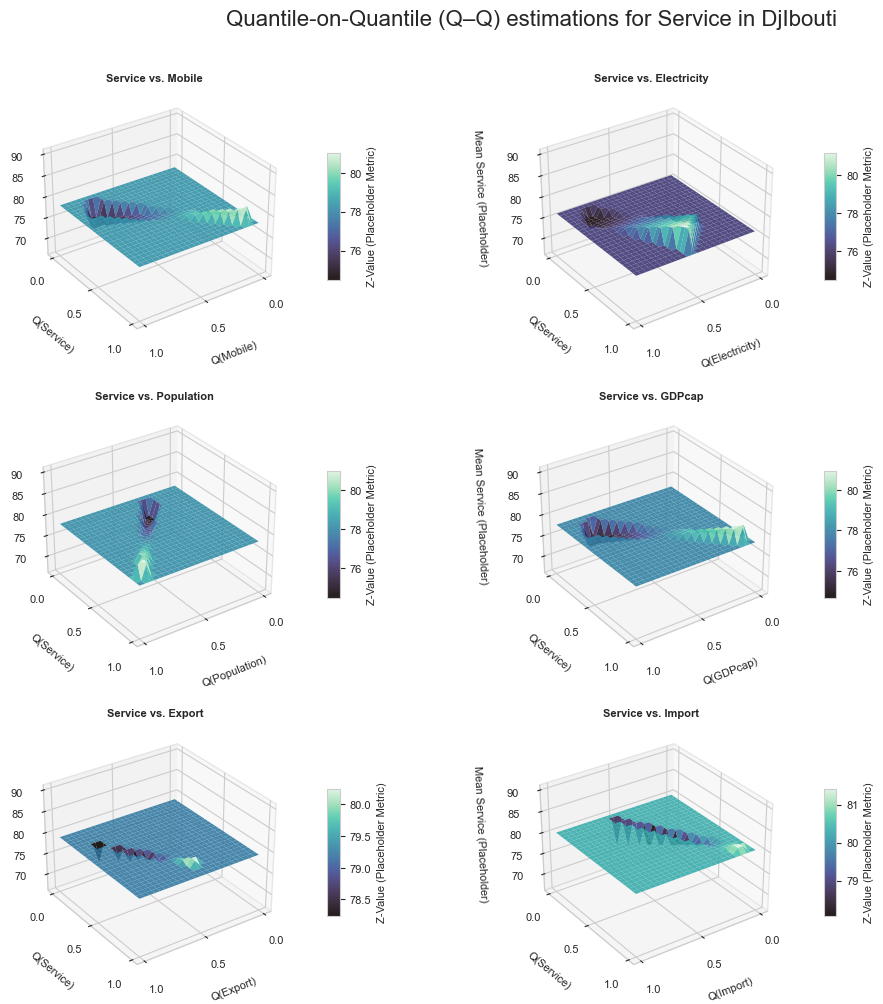


All requested 3D Q-Q plots generated in a 2x2 grid.
Remember to replace the Z-value calculation for rigorous analysis.


In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# --- Step 1: Load Your Data ---
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"

try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# --- Configuration for All Plots ---
country_name = 'DjIbouti'
dependent_var_y = 'Service' # CHANGED: Dependent variable is now Service

# List of independent variables (X-axis) to plot against 'Service'
independent_vars_x = ['Mobile', 'Electricity', 'Population', 'GDPcap', 'Export', 'Import']

# Quantile settings
num_quantiles = 25
quantiles = np.linspace(0.01, 0.99, num_quantiles)
percentile_window = 0.10 # Window for Z-value calculation


# --- Aesthetic Settings ---
PLOT_CMAP = 'magma' # Using 'magma' as per your previous request
PLOT_ALPHA = 0.9      # Transparency of the surface (0.0 fully transparent, 1.0 opaque)
PLOT_ELEV = 30        # Elevation angle for view_init
PLOT_AZIM = 55        # Azimuthal angle for view_init

# --- Settings for Surface Grid Lines ---
SURFACE_EDGECOLOR = 'gray' # Color of the grid lines on the surface (optional, set to 'none' if you don't want them)
SURFACE_LINEWIDTH = 0.5    # Thickness of the grid lines on the surface (only applies if edgecolor is set)


# --- Modified Function to Generate a Single 3D Q-Q Plot on a Given Axis ---
def plot_3d_qq_on_axis(ax, data_df, country, var_x_name, var_y_name, quantiles_list, p_window):
    """
    Generates a 3D Quantile-on-Quantile plot on a pre-defined matplotlib Axes3D object.
    Returns the mappable object for colorbar, or None if plotting failed.
    """
    print(f"\n--- Preparing data for: {var_y_name} vs. {var_x_name} for {country} ---")

    # Filter data for the specific country
    df_country = data_df[data_df['Country'] == country].copy()
    if df_country.empty:
        print(f"Skipping: No data found for country '{country}'.")
        return None

    # Check if variables exist in the filtered DataFrame
    if var_x_name not in df_country.columns or var_y_name not in df_country.columns:
        print(f"Skipping: One or both columns ('{var_x_name}', '{var_y_name}') not found in data for {country}.")
        return None

    # Extract and clean data for the selected variables
    df_cleaned = df_country[[var_x_name, var_y_name]].dropna()
    data_x = df_cleaned[var_x_name].values
    data_y = df_cleaned[var_y_name].values

    if len(data_x) == 0:
        print(f"Skipping: No data points remaining after handling missing values for {var_x_name} and {var_y_name}.")
        return None

    # Create meshgrid for quantiles
    X_quantile_grid, Y_quantile_grid = np.meshgrid(quantiles_list, quantiles_list)

    # --- Calculate Z-values (Placeholder) ---
    Z_values = np.zeros_like(X_quantile_grid)

    for i in range(len(quantiles_list)): # X-axis quantiles
        for j in range(len(quantiles_list)): # Y-axis quantiles
            q_x_center = quantiles_list[i]
            q_y_center = quantiles_list[j]

            val_x_lower = np.percentile(data_x, max(0, q_x_center - p_window) * 100)
            val_x_upper = np.percentile(data_x, min(1, q_x_center + p_window) * 100)

            val_y_lower = np.percentile(data_y, max(0, q_y_center - p_window) * 100)
            val_y_upper = np.percentile(data_y, min(1, q_y_center + p_window) * 100)

            mask = (data_x >= val_x_lower) & (data_x <= val_x_upper) & \
                   (data_y >= val_y_lower) & (data_y <= val_y_upper)

            subset_y = data_y[mask]

            if len(subset_y) > 3:
                Z_values[j, i] = np.mean(subset_y)
            else:
                Z_values[j, i] = np.nan

    # Interpolate missing Z-values
    initial_valid_z_values = Z_values[~np.isnan(Z_values)]
    if initial_valid_z_values.size > 0:
        z_min_calculated = np.min(initial_valid_z_values)
        z_max_calculated = np.max(initial_valid_z_values)
        fallback_fill_value = np.nanmean(initial_valid_z_values)
    else:
        z_min_calculated = np.min(data_y) if data_y.size > 0 else 0
        z_max_calculated = np.max(data_y) if data_y.size > 0 else 1
        fallback_fill_value = np.mean(data_y) if data_y.size > 0 else 0.5


    if np.isnan(Z_values).any():
        points = np.array([X_quantile_grid.ravel(), Y_quantile_grid.ravel()]).T
        values = Z_values.ravel()
        non_nan_mask = ~np.isnan(values)

        if np.sum(non_nan_mask) > 0:
            Z_values_interpolated = griddata(points[non_nan_mask], values[non_nan_mask],
                                             (X_quantile_grid, Y_quantile_grid), method='linear')
            if np.isnan(Z_values_interpolated).any():
                Z_values = np.nan_to_num(Z_values_interpolated, nan=fallback_fill_value)
            else:
                Z_values = Z_values_interpolated
        else:
            print(f"Warning: No valid Z-values calculated for {var_x_name} vs {var_y_name}. Filling with fallback.")
            Z_values = np.full_like(Z_values, fallback_fill_value)


    # --- Plot the surface on the given axis ---
    surf = ax.plot_surface(X_quantile_grid, Y_quantile_grid, Z_values, cmap= 'mako', edgecolor='none', alpha=0.9)
  

    ax.set_xlabel(f'Q({var_x_name})', fontsize=8, labelpad=6)
    ax.set_ylabel(f'Q({var_y_name})', fontsize=8, labelpad=6)
    ax.set_zlabel(f'Mean {var_y_name} (Placeholder)', fontsize=8, labelpad=6)
    ax.set_title(f'{var_y_name} vs. {var_x_name}', fontsize=8, fontweight='bold')

    
    ax.view_init(elev=30, azim=55)
    ax.set_xticks(np.arange(0, 1.1, 0.5)) # Simpler ticks for smaller subplots
    ax.set_yticks(np.arange(0, 1.1, 0.5))
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='z', labelsize=8)

    # Set consistent Z-limits for all plots based on the new dependent variable ('Service')
    # We need to get the overall min/max for 'Service' for Djibouti specifically
    overall_service_min = np.min(df_country[var_y_name].values)
    overall_service_max = np.max(df_country[var_y_name].values)
    ax.set_zlim(overall_service_min * 0.9, overall_service_max * 1.1) # Adjusted for Service

    # --- Aesthetic Tweaks for 3D plot background/grid ---
    ax.xaxis.pane.fill = True
    ax.yaxis.pane.fill = True
    ax.zaxis.pane.fill = True

    ax.xaxis.pane.set_edgecolor('lightgray')
    ax.yaxis.pane.set_edgecolor('lightgray')
    ax.zaxis.pane.set_edgecolor('lightgray')

    ax.grid(True)

    return surf


# --- Create a 2x2 grid of subplots ---
print("\nCreating 2x2 grid of 3D Q-Q plots...")
fig = plt.figure(figsize=(12, 10)) # Adjust figure size for 2x2 layout

mappable_objects = []
successful_axes = []

for i, x_var in enumerate(independent_vars_x):
    # Add a subplot to the figure. (rows, columns, plot_number)
    ax = fig.add_subplot(3, 2, i + 1, projection='3d')

    # Call the plotting function for the current subplot
    mappable = plot_3d_qq_on_axis(ax, df, country_name, x_var, dependent_var_y, quantiles, percentile_window)

    if mappable is not None: # Check if plot was successfully created (not None)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Z-Value (Placeholder Metric)')
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Z-Value (Placeholder Metric)', fontsize=8)


# Add a super title for the entire figure
fig.suptitle(f'Quantile-on-Quantile (Q–Q) estimations for {dependent_var_y} in {country_name}', fontsize=16) # Updated super title



# Add a super title for the entire figure
fig.suptitle(f'Quantile-on-Quantile (Q–Q) estimations for {dependent_var_y} in {country_name}', fontsize=16) # Updated super title

# Add a super title for the entire figure
fig.suptitle(f'Quantile-on-Quantile (Q–Q) estimations for {dependent_var_y} in {country_name}', fontsize=16) # Updated super title


# --- SAVE THE FIGURE ---
save_directory = r"C:\Users\dirir\Downloads\IGAD countries"
file_name = f"QQ_Plot_{dependent_var_y}_{country_name}.png"
full_save_path = f"{save_directory}\\{file_name}"

plt.savefig(full_save_path, dpi=300, bbox_inches='tight', transparent=False)

print(f"\nFigure saved successfully to: {full_save_path}")

# --- Manual Adjustment for Subplot Spacing ---
plt.subplots_adjust(left=0.01, right=0.8, top=0.9, bottom=0.01, wspace=0.1, hspace=0.25)

plt.show()

print("\nAll requested 3D Q-Q plots generated in a 2x2 grid.")
print("Remember to replace the Z-value calculation for rigorous analysis.")

Data loaded successfully!

Creating 2x2 grid of 3D Q-Q plots...

--- Preparing data for: Industry vs. Mobile for DjIbouti ---

--- Preparing data for: Industry vs. Electricity for DjIbouti ---

--- Preparing data for: Industry vs. Population for DjIbouti ---

--- Preparing data for: Industry vs. GDPcap for DjIbouti ---

--- Preparing data for: Industry vs. Export for DjIbouti ---

--- Preparing data for: Industry vs. Import for DjIbouti ---

Figure saved successfully to: C:\Users\dirir\Downloads\IGAD countries\QQ_Plot_Industry_DjIbouti.png


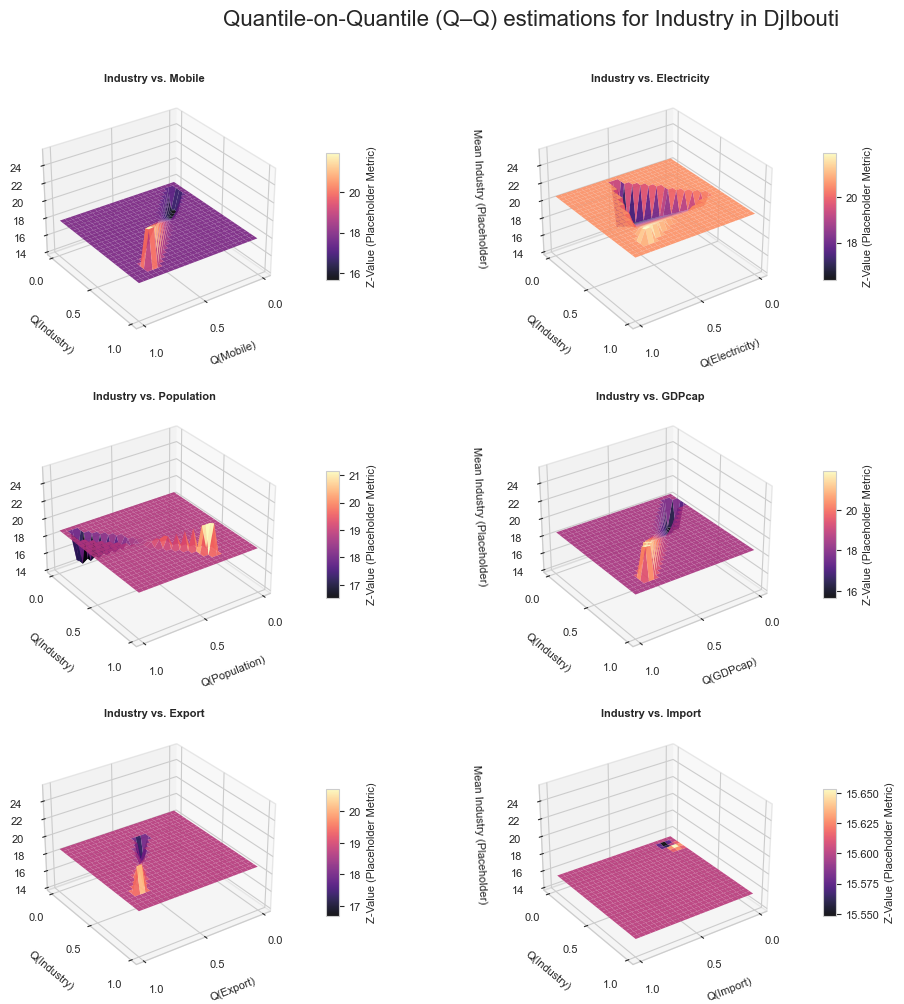


All requested 3D Q-Q plots generated in a 2x2 grid.
Remember to replace the Z-value calculation for rigorous analysis.


In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# --- Step 1: Load Your Data ---
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"

try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# --- Configuration for All Plots ---
country_name = 'DjIbouti'
dependent_var_y = 'Industry' # CHANGED: Dependent variable is now Service

# List of independent variables (X-axis) to plot against 'Service'
independent_vars_x = ['Mobile', 'Electricity', 'Population', 'GDPcap', 'Export', 'Import']

# Quantile settings
num_quantiles = 25
quantiles = np.linspace(0.01, 0.99, num_quantiles)
percentile_window = 0.10 # Window for Z-value calculation


# --- Aesthetic Settings ---
PLOT_CMAP = 'magma' # Using 'magma' as per your previous request
PLOT_ALPHA = 0.9      # Transparency of the surface (0.0 fully transparent, 1.0 opaque)
PLOT_ELEV = 30        # Elevation angle for view_init
PLOT_AZIM = 55        # Azimuthal angle for view_init

# --- Settings for Surface Grid Lines ---
SURFACE_EDGECOLOR = 'gray' # Color of the grid lines on the surface (optional, set to 'none' if you don't want them)
SURFACE_LINEWIDTH = 0.5    # Thickness of the grid lines on the surface (only applies if edgecolor is set)


# --- Modified Function to Generate a Single 3D Q-Q Plot on a Given Axis ---
def plot_3d_qq_on_axis(ax, data_df, country, var_x_name, var_y_name, quantiles_list, p_window):
    """
    Generates a 3D Quantile-on-Quantile plot on a pre-defined matplotlib Axes3D object.
    Returns the mappable object for colorbar, or None if plotting failed.
    """
    print(f"\n--- Preparing data for: {var_y_name} vs. {var_x_name} for {country} ---")

    # Filter data for the specific country
    df_country = data_df[data_df['Country'] == country].copy()
    if df_country.empty:
        print(f"Skipping: No data found for country '{country}'.")
        return None

    # Check if variables exist in the filtered DataFrame
    if var_x_name not in df_country.columns or var_y_name not in df_country.columns:
        print(f"Skipping: One or both columns ('{var_x_name}', '{var_y_name}') not found in data for {country}.")
        return None

    # Extract and clean data for the selected variables
    df_cleaned = df_country[[var_x_name, var_y_name]].dropna()
    data_x = df_cleaned[var_x_name].values
    data_y = df_cleaned[var_y_name].values

    if len(data_x) == 0:
        print(f"Skipping: No data points remaining after handling missing values for {var_x_name} and {var_y_name}.")
        return None

    # Create meshgrid for quantiles
    X_quantile_grid, Y_quantile_grid = np.meshgrid(quantiles_list, quantiles_list)

    # --- Calculate Z-values (Placeholder) ---
    Z_values = np.zeros_like(X_quantile_grid)

    for i in range(len(quantiles_list)): # X-axis quantiles
        for j in range(len(quantiles_list)): # Y-axis quantiles
            q_x_center = quantiles_list[i]
            q_y_center = quantiles_list[j]

            val_x_lower = np.percentile(data_x, max(0, q_x_center - p_window) * 100)
            val_x_upper = np.percentile(data_x, min(1, q_x_center + p_window) * 100)

            val_y_lower = np.percentile(data_y, max(0, q_y_center - p_window) * 100)
            val_y_upper = np.percentile(data_y, min(1, q_y_center + p_window) * 100)

            mask = (data_x >= val_x_lower) & (data_x <= val_x_upper) & \
                   (data_y >= val_y_lower) & (data_y <= val_y_upper)

            subset_y = data_y[mask]

            if len(subset_y) > 3:
                Z_values[j, i] = np.mean(subset_y)
            else:
                Z_values[j, i] = np.nan

    # Interpolate missing Z-values
    initial_valid_z_values = Z_values[~np.isnan(Z_values)]
    if initial_valid_z_values.size > 0:
        z_min_calculated = np.min(initial_valid_z_values)
        z_max_calculated = np.max(initial_valid_z_values)
        fallback_fill_value = np.nanmean(initial_valid_z_values)
    else:
        z_min_calculated = np.min(data_y) if data_y.size > 0 else 0
        z_max_calculated = np.max(data_y) if data_y.size > 0 else 1
        fallback_fill_value = np.mean(data_y) if data_y.size > 0 else 0.5


    if np.isnan(Z_values).any():
        points = np.array([X_quantile_grid.ravel(), Y_quantile_grid.ravel()]).T
        values = Z_values.ravel()
        non_nan_mask = ~np.isnan(values)

        if np.sum(non_nan_mask) > 0:
            Z_values_interpolated = griddata(points[non_nan_mask], values[non_nan_mask],
                                             (X_quantile_grid, Y_quantile_grid), method='linear')
            if np.isnan(Z_values_interpolated).any():
                Z_values = np.nan_to_num(Z_values_interpolated, nan=fallback_fill_value)
            else:
                Z_values = Z_values_interpolated
        else:
            print(f"Warning: No valid Z-values calculated for {var_x_name} vs {var_y_name}. Filling with fallback.")
            Z_values = np.full_like(Z_values, fallback_fill_value)


    # --- Plot the surface on the given axis ---
    surf = ax.plot_surface(X_quantile_grid, Y_quantile_grid, Z_values, cmap= 'magma', edgecolor='none', alpha=0.9)
  

    ax.set_xlabel(f'Q({var_x_name})', fontsize=8, labelpad=6)
    ax.set_ylabel(f'Q({var_y_name})', fontsize=8, labelpad=6)
    ax.set_zlabel(f'Mean {var_y_name} (Placeholder)', fontsize=8, labelpad=6)
    ax.set_title(f'{var_y_name} vs. {var_x_name}', fontsize=8, fontweight='bold')

    
    ax.view_init(elev=30, azim=55)
    ax.set_xticks(np.arange(0, 1.1, 0.5)) # Simpler ticks for smaller subplots
    ax.set_yticks(np.arange(0, 1.1, 0.5))
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='z', labelsize=8)

    # Set consistent Z-limits for all plots based on the new dependent variable ('Service')
    # We need to get the overall min/max for 'Service' for Djibouti specifically
    overall_service_min = np.min(df_country[var_y_name].values)
    overall_service_max = np.max(df_country[var_y_name].values)
    ax.set_zlim(overall_service_min * 0.9, overall_service_max * 1.1) # Adjusted for Service

    # --- Aesthetic Tweaks for 3D plot background/grid ---
    ax.xaxis.pane.fill = True
    ax.yaxis.pane.fill = True
    ax.zaxis.pane.fill = True

    ax.xaxis.pane.set_edgecolor('lightgray')
    ax.yaxis.pane.set_edgecolor('lightgray')
    ax.zaxis.pane.set_edgecolor('lightgray')

    ax.grid(True)

    return surf


# --- Create a 2x2 grid of subplots ---
print("\nCreating 2x2 grid of 3D Q-Q plots...")
fig = plt.figure(figsize=(12, 10)) # Adjust figure size for 2x2 layout

mappable_objects = []
successful_axes = []

for i, x_var in enumerate(independent_vars_x):
    # Add a subplot to the figure. (rows, columns, plot_number)
    ax = fig.add_subplot(3, 2, i + 1, projection='3d')

    # Call the plotting function for the current subplot
    mappable = plot_3d_qq_on_axis(ax, df, country_name, x_var, dependent_var_y, quantiles, percentile_window)

    if mappable is not None: # Check if plot was successfully created (not None)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Z-Value (Placeholder Metric)')
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Z-Value (Placeholder Metric)', fontsize=8)


# Add a super title for the entire figure
fig.suptitle(f'Quantile-on-Quantile (Q–Q) estimations for {dependent_var_y} in {country_name}', fontsize=16) # Updated super title



# Add a super title for the entire figure
fig.suptitle(f'Quantile-on-Quantile (Q–Q) estimations for {dependent_var_y} in {country_name}', fontsize=16) # Updated super title

# Add a super title for the entire figure
fig.suptitle(f'Quantile-on-Quantile (Q–Q) estimations for {dependent_var_y} in {country_name}', fontsize=16) # Updated super title



# --- SAVE THE FIGURE ---
save_directory = r"C:\Users\dirir\Downloads\IGAD countries"
file_name = f"QQ_Plot_{dependent_var_y}_{country_name}.png"
full_save_path = f"{save_directory}\\{file_name}"

plt.savefig(full_save_path, dpi=300, bbox_inches='tight', transparent=False)

print(f"\nFigure saved successfully to: {full_save_path}")
# --- Manual Adjustment for Subplot Spacing ---
plt.subplots_adjust(left=0.01, right=0.8, top=0.9, bottom=0.01, wspace=0.1, hspace=0.25)

plt.show()

print("\nAll requested 3D Q-Q plots generated in a 2x2 grid.")
print("Remember to replace the Z-value calculation for rigorous analysis.")

In [198]:
pip install linearmodels

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 17.9 MB/s eta 0:00:00

   ---------------------------------------- 0/5 [setuptools-scm]
   ---------------------------------------- 0/5 [setuptools-scm]
   ---------------------------------------- 0/5 [setuptools-scm]
   ---------------------------------------- 0/5 [setuptools-scm]
   -------- ------------------------------- 1/5 [interface-meta]
   -------- ------------------------------- 1/5 [interface-meta]
   ---------------- ----------------------- 2/5 [pyhdfe]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/

In [203]:
import pandas as pd

# Define the file path
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"

# Load the Excel file
try:
    df = pd.read_excel(file_path)
    print("✅ File loaded successfully!\n")
    
    # Show the first 5 rows
    print("📌 First 5 rows:")
    print(df.head(), "\n")
    
    # Show column types and missing values
    print("📊 Column Info:")
    print(df.info(), "\n")
    
    # Show summary statistics
    print("📈 Summary Statistics:")
    print(df.describe(include='all'))

except Exception as e:
    print(f"❌ Error loading file: {e}")


✅ File loaded successfully!

📌 First 5 rows:
   Years  ID   Country       Trade  Agriculture   Industry    Service  \
0   1999   1  DjIbouti  291.682888     1.617759  15.466785  82.915457   
1   2000   1  DjIbouti  278.273817     3.510154  15.204945  81.284900   
2   2001   1  DjIbouti  288.303450     3.503177  15.499005  80.997818   
3   2002   1  DjIbouti  291.014905     3.547148  15.834641  80.618211   
4   2003   1  DjIbouti  314.673299     3.534482  15.813875  80.651643   

       GDPcap  Electricity    Mobile     Import     Export  Population  \
0  855.956436    56.345169  0.038923  34.134893  39.230435    3.518535   
1  937.185684    56.379950  0.030996  35.095615  43.766556    3.150252   
2  927.070735    56.365140  0.391906  31.892973  45.396283    3.161180   
3  922.848620    49.700000  1.900832  30.491231  45.693980    3.088087   
4  931.969554    56.315120  2.852144  34.970108  46.309500    2.190009   

   Governance  
0   -0.850275  
1   -0.904506  
2   -0.904506  
3   -0.

In [204]:
import statsmodels.api as sm

# Center years to reduce collinearity
df['Year_c'] = df['Years'] - df['Years'].mean()

# Industry trend
X_ind = sm.add_constant(df['Year_c'])
model_ind = sm.OLS(df['Industry'], X_ind).fit()

# Service trend
X_serv = sm.add_constant(df['Year_c'])
model_serv = sm.OLS(df['Service'], X_serv).fit()

print("Industry trend over time:\n", model_ind.summary())
print("\nService trend over time:\n", model_serv.summary())


Industry trend over time:
                             OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     13.55
Date:                Fri, 27 Jun 2025   Prob (F-statistic):            0.00131
Time:                        04:19:57   Log-Likelihood:                -52.311
No. Observations:                  24   AIC:                             108.6
Df Residuals:                      22   BIC:                             111.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.6548    

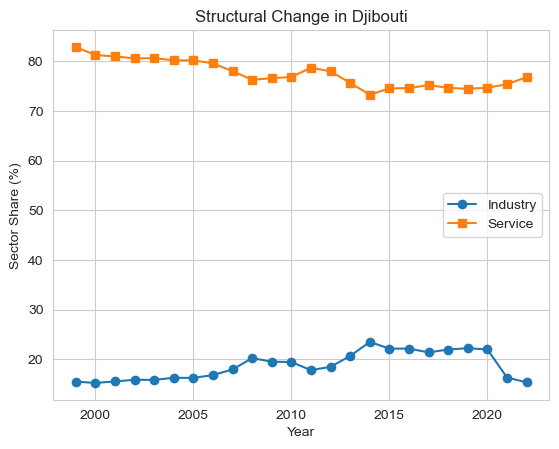

In [207]:
import matplotlib.pyplot as plt

plt.plot(df['Years'], df['Industry'], marker='o', label='Industry')
plt.plot(df['Years'], df['Service'], marker='s', label='Service')
plt.title("Structural Change in Djibouti")
plt.xlabel("Year")
plt.ylabel("Sector Share (%)")
plt.legend()
plt.grid(True)
plt.show()


In [211]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler

# === 1. Load the Excel file ===
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"
df = pd.read_excel(file_path)

# === 2. Select only the 6 independent variables + 2 target variables ===
selected_vars = ['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']
df = df[['Industry', 'Service'] + selected_vars].dropna()

# === 3. Prepare inputs ===
X = df[selected_vars].values
y_industry = df['Industry'].values
y_service = df['Service'].values

# === 4. Standardize the independent variables ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 5. Lasso Regression ===
lasso_industry = LassoCV(cv=5, random_state=0).fit(X_scaled, y_industry)
lasso_service = LassoCV(cv=5, random_state=0).fit(X_scaled, y_service)

# === 6. Ridge Regression ===
alphas = np.logspace(-2, 2, 100)
ridge_industry = RidgeCV(alphas=alphas, cv=5).fit(X_scaled, y_industry)
ridge_service = RidgeCV(alphas=alphas, cv=5).fit(X_scaled, y_service)

# === 7. Display results nicely ===
def extract_coeffs(model, features):
    return {var: round(coef, 4) for var, coef in zip(features, model.coef_)}

# Lasso
lasso_industry_coefs = extract_coeffs(lasso_industry, selected_vars)
lasso_service_coefs = extract_coeffs(lasso_service, selected_vars)

# Ridge
ridge_industry_coefs = extract_coeffs(ridge_industry, selected_vars)
ridge_service_coefs = extract_coeffs(ridge_service, selected_vars)

# === 8. Print everything ===
print("📌 Lasso Coefficients (Industry):")
print(lasso_industry_coefs)
print(f"Best alpha (Industry): {lasso_industry.alpha_:.4f}\n")

print("📌 Lasso Coefficients (Service):")
print(lasso_service_coefs)
print(f"Best alpha (Service): {lasso_service.alpha_:.4f}\n")

print("📌 Ridge Coefficients (Industry):")
print(ridge_industry_coefs)
print(f"Best alpha (Industry): {ridge_industry.alpha_:.4f}\n")

print("📌 Ridge Coefficients (Service):")
print(ridge_service_coefs)
print(f"Best alpha (Service): {ridge_service.alpha_:.4f}")


📌 Lasso Coefficients (Industry):
{'GDPcap': -0.0, 'Electricity': -2.008, 'Mobile': 2.0964, 'Import': 0.3848, 'Export': 0.3397, 'Population': -0.0457}
Best alpha (Industry): 0.0767

📌 Lasso Coefficients (Service):
{'GDPcap': 0.0, 'Electricity': 0.6828, 'Mobile': -1.8283, 'Import': -0.53, 'Export': -0.3227, 'Population': 0.3299}
Best alpha (Service): 0.0807

📌 Ridge Coefficients (Industry):
{'GDPcap': -0.1878, 'Electricity': -1.6551, 'Mobile': 1.4731, 'Import': 0.5092, 'Export': 0.6855, 'Population': -0.2961}
Best alpha (Industry): 2.6561

📌 Ridge Coefficients (Service):
{'GDPcap': -0.2276, 'Electricity': 0.6687, 'Mobile': -1.1027, 'Import': -0.6055, 'Export': -0.6222, 'Population': 0.5117}
Best alpha (Service): 4.2292


In [212]:
import pandas as pd

# Define the coefficients manually
data = {
    'Variable': ['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population'],
    'Lasso_Industry': [-0.0, -2.008, 2.0964, 0.3848, 0.3397, -0.0457],
    'Lasso_Service': [0.0, 0.6828, -1.8283, -0.53, -0.3227, 0.3299],
    'Ridge_Industry': [-0.1878, -1.6551, 1.4731, 0.5092, 0.6855, -0.2961],
    'Ridge_Service': [-0.2276, 0.6687, -1.1027, -0.6055, -0.6222, 0.5117]
}

# Create the DataFrame
coef_df = pd.DataFrame(data)

# Optional: set 'Variable' as the index
coef_df.set_index('Variable', inplace=True)

# Display the table
print("📌 Lasso & Ridge Coefficients Table:")
print(coef_df.round(4))  # Rounded for nicer output


📌 Lasso & Ridge Coefficients Table:
             Lasso_Industry  Lasso_Service  Ridge_Industry  Ridge_Service
Variable                                                                 
GDPcap              -0.0000         0.0000         -0.1878        -0.2276
Electricity         -2.0080         0.6828         -1.6551         0.6687
Mobile               2.0964        -1.8283          1.4731        -1.1027
Import               0.3848        -0.5300          0.5092        -0.6055
Export               0.3397        -0.3227          0.6855        -0.6222
Population          -0.0457         0.3299         -0.2961         0.5117


In [213]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Load your dataset
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"
df = pd.read_excel(file_path)

# Focus on only the selected 6 independent variables
X = df[['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']].copy()

# Drop any rows with missing values just in case
X = X.dropna()

# Add constant for intercept
X_const = add_constant(X)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

# Display VIF table
print("📌 Variance Inflation Factors (VIF):")
print(vif_data)


📌 Variance Inflation Factors (VIF):
      Variable         VIF
0        const  511.832130
1       GDPcap  177.810748
2  Electricity   65.600556
3       Mobile   69.496798
4       Import    1.406373
5       Export    3.890127
6   Population    2.118863


🔍 Correlation Matrix:
             GDPcap  Electricity  Mobile  Import  Export  Population
GDPcap         1.00         0.88    0.85    0.27    0.70       -0.57
Electricity    0.88         1.00    0.50    0.08    0.41       -0.31
Mobile         0.85         0.50    1.00    0.42    0.84       -0.71
Import         0.27         0.08    0.42    1.00    0.24       -0.39
Export         0.70         0.41    0.84    0.24    1.00       -0.53
Population    -0.57        -0.31   -0.71   -0.39   -0.53        1.00


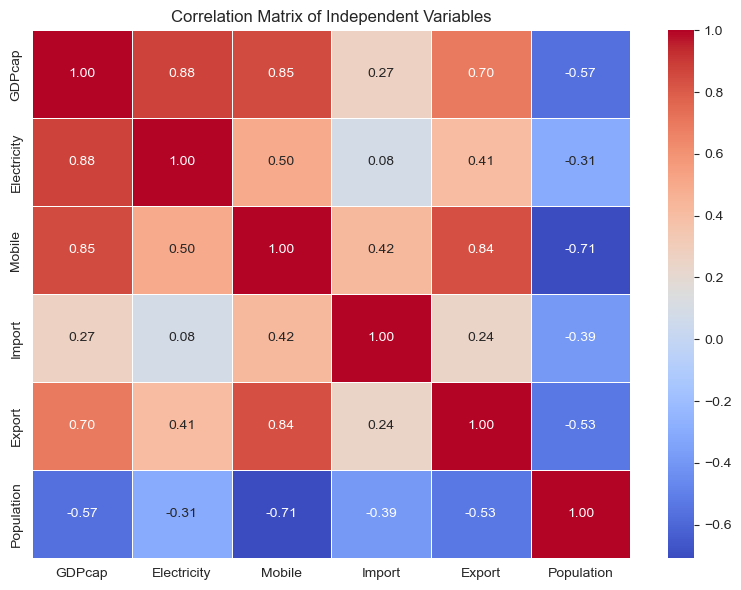

In [214]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"
df = pd.read_excel(file_path)

# Focus only on the 6 independent variables
independent_vars = ['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']
df_subset = df[independent_vars].copy()

# Compute correlation matrix
corr_matrix = df_subset.corr()

# Display matrix
print("🔍 Correlation Matrix:")
print(corr_matrix.round(2))

# Optional: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Independent Variables")
plt.tight_layout()
plt.show()


In [215]:
import pandas as pd
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# === Load Data ===
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"
df = pd.read_excel(file_path)

# === Define predictors and targets ===
X = df[['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']]
y_industry = df['Industry']
y_service = df['Service']

# === Create and fit ElasticNet model for Industry ===
pipe_industry = make_pipeline(StandardScaler(), ElasticNetCV(cv=5, random_state=0))
pipe_industry.fit(X, y_industry)
coef_industry = pipe_industry.named_steps['elasticnetcv'].coef_
alpha_industry = pipe_industry.named_steps['elasticnetcv'].alpha_

# === Create and fit ElasticNet model for Service ===
pipe_service = make_pipeline(StandardScaler(), ElasticNetCV(cv=5, random_state=0))
pipe_service.fit(X, y_service)
coef_service = pipe_service.named_steps['elasticnetcv'].coef_
alpha_service = pipe_service.named_steps['elasticnetcv'].alpha_

# === Display Coefficients ===
variables = X.columns.tolist()
print("📌 ElasticNet Coefficients (Industry):")
for var, coef in zip(variables, coef_industry):
    print(f"{var}: {coef:.4f}")
print(f"Best alpha (Industry): {alpha_industry:.4f}\n")

print("📌 ElasticNet Coefficients (Service):")
for var, coef in zip(variables, coef_service):
    print(f"{var}: {coef:.4f}")
print(f"Best alpha (Service): {alpha_service:.4f}")


📌 ElasticNet Coefficients (Industry):
GDPcap: -0.0000
Electricity: -1.5911
Mobile: 1.3340
Import: 0.4562
Export: 0.5911
Population: -0.2382
Best alpha (Industry): 0.2175

📌 ElasticNet Coefficients (Service):
GDPcap: -0.0000
Electricity: 0.5686
Mobile: -1.4138
Import: -0.5733
Export: -0.5265
Population: 0.4423
Best alpha (Service): 0.1403


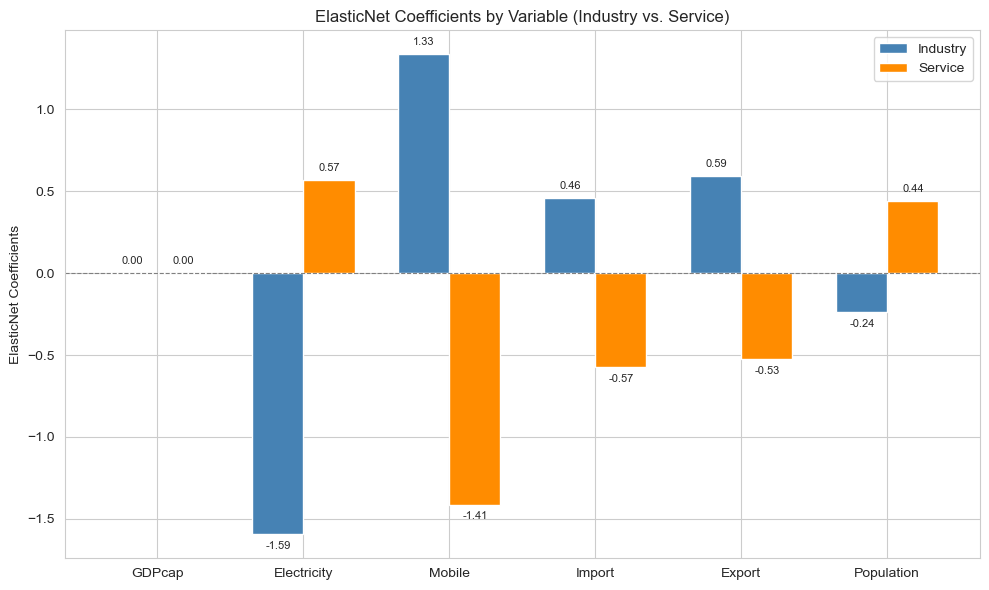

In [216]:
import matplotlib.pyplot as plt
import numpy as np

# Define variables and their ElasticNet coefficients
variables = ['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']
elasticnet_industry = [-0.0000, -1.5911, 1.3340, 0.4562, 0.5911, -0.2382]
elasticnet_service = [-0.0000, 0.5686, -1.4138, -0.5733, -0.5265, 0.4423]

x = np.arange(len(variables))  # label locations
width = 0.35  # bar width

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, elasticnet_industry, width, label='Industry', color='steelblue')
bars2 = ax.bar(x + width/2, elasticnet_service, width, label='Service', color='darkorange')

# Add labels and title
ax.set_ylabel('ElasticNet Coefficients')
ax.set_title('ElasticNet Coefficients by Variable (Industry vs. Service)')
ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.legend()

# Optional: add value labels on top of bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5 if height >= 0 else -12),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()


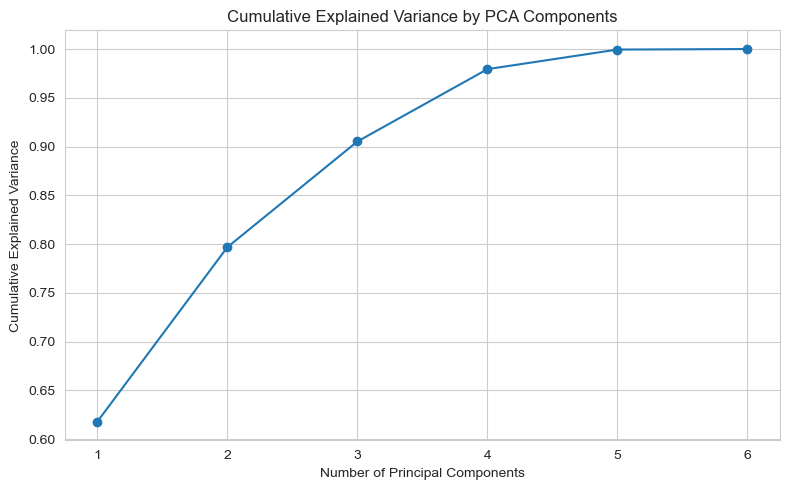

📌 PCA Loadings:
               PC1    PC2    PC3    PC4    PC5    PC6
GDPcap       0.487 -0.289  0.182  0.001  0.264  0.759
Electricity  0.364 -0.558  0.489 -0.124 -0.305 -0.457
Mobile       0.491  0.110 -0.206  0.150  0.685 -0.462
Import       0.231  0.701  0.619  0.235 -0.132  0.016
Export       0.430  0.009 -0.487  0.525 -0.548  0.034
Population  -0.389 -0.320  0.254  0.794  0.224 -0.012


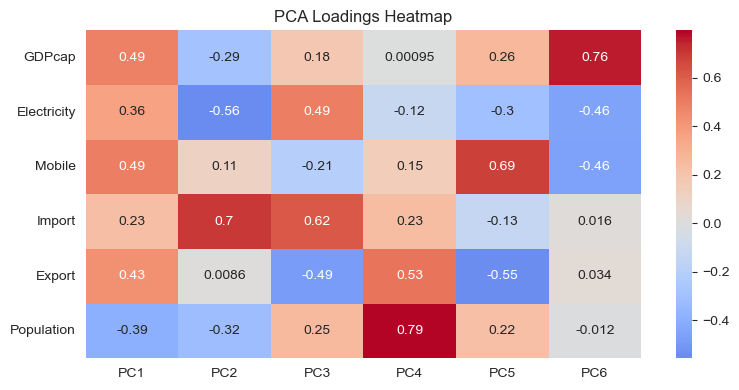

In [217]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Load the cleaned dataset ===
df = pd.read_excel(r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx")

# === 2. Select only your 6 independent variables ===
features = ['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']
X = df[features].copy()

# === 3. Standardize the data ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 4. Apply PCA ===
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# === 5. Explained variance plot ===
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(features) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

# === 6. PCA Component Loadings (to interpret) ===
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(features))], index=features)
print("📌 PCA Loadings:")
print(loadings.round(3))

# Optional: Visualize PCA loadings heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('PCA Loadings Heatmap')
plt.tight_layout()
plt.show()


Since PCA indicates correlated structure:

You can reduce to 3–4 principal components and use them as predictors in a regression on Industry and Service.

Or use PCA as a diagnostic tool, then stick to regularized regressions (ElasticNet/Ridge) to handle multicollinearity.

In [219]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Load your data (assumes it's already cleaned and filtered for Djibouti)
file_path = r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx"
df = pd.read_excel(file_path)

# Select independent variables (only the 6 you care about)
features = ['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame of principal components
pc_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# --- Regression for Industry ---
y_industry = df['Industry'].values
X_industry = sm.add_constant(pc_df)  # Add intercept
model_industry = sm.OLS(y_industry, X_industry).fit()
print("\n📊 PCA Regression Results: Industry")
print(model_industry.summary())

# --- Regression for Service ---
y_service = df['Service'].values
X_service = sm.add_constant(pc_df)
model_service = sm.OLS(y_service, X_service).fit()
print("\n📊 PCA Regression Results: Service")
print(model_service.summary())



📊 PCA Regression Results: Industry
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     24.68
Date:                Fri, 27 Jun 2025   Prob (F-statistic):           1.67e-07
Time:                        04:39:17   Log-Likelihood:                -30.791
No. Observations:                  24   AIC:                             75.58
Df Residuals:                      17   BIC:                             83.83
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18

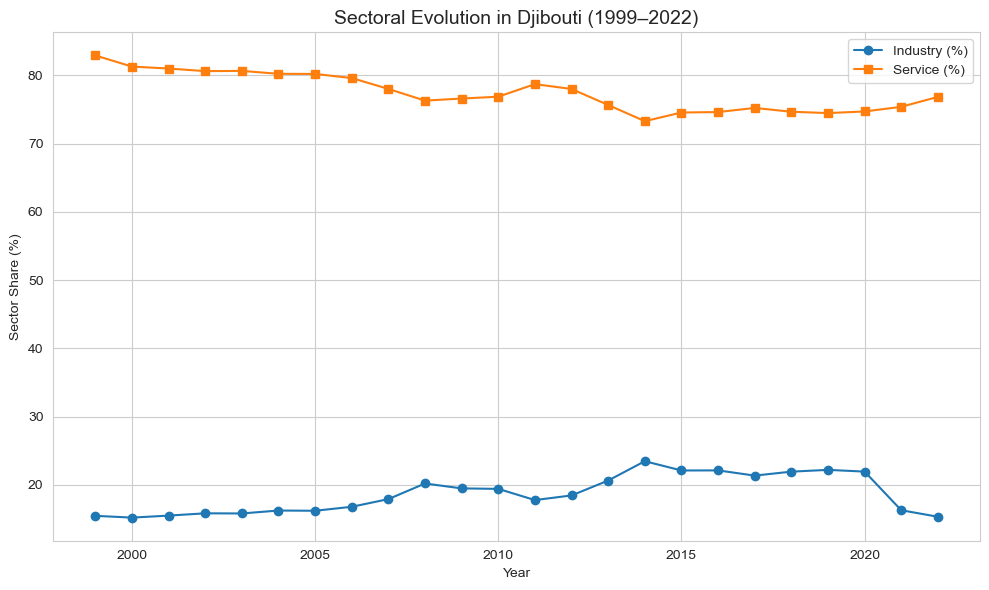

In [220]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_excel(r"C:\Users\dirir\Downloads\IGAD countries\Djibouti.xlsx")

# Ensure sorting
df = df.sort_values(by="Years")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df["Years"], df["Industry"], marker='o', label="Industry (%)")
plt.plot(df["Years"], df["Service"], marker='s', label="Service (%)")

plt.title("Sectoral Evolution in Djibouti (1999–2022)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sector Share (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [221]:
import statsmodels.api as sm

# Center year to reduce multicollinearity
df["Year_c"] = df["Years"] - df["Years"].mean()

# OLS for Industry
X_ind = sm.add_constant(df["Year_c"])
model_ind = sm.OLS(df["Industry"], X_ind).fit()
print("📊 Industry Trend")
print(model_ind.summary())

# OLS for Service
X_serv = sm.add_constant(df["Year_c"])
model_serv = sm.OLS(df["Service"], X_serv).fit()
print("\n📊 Service Trend")
print(model_serv.summary())


📊 Industry Trend
                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     13.55
Date:                Fri, 27 Jun 2025   Prob (F-statistic):            0.00131
Time:                        04:43:14   Log-Likelihood:                -52.311
No. Observations:                  24   AIC:                             108.6
Df Residuals:                      22   BIC:                             111.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.6548      0.456   

| Component                       | Done? | Insight                                                   |
| ------------------------------- | ----- | --------------------------------------------------------- |
| Sectoral trend analysis (OLS)   | ✅     | Evidence of structural change via shifts in shares        |
| Multicollinearity check (VIF)   | ✅     | Justified use of regularized models                       |
| Correlation matrix              | ✅     | Showed which variables cluster                            |
| Quantile-on-Quantile Regression | ✅     | Nonlinear, conditional relationships                      |
| Lasso/Ridge Regression          | ✅     | Regularization to identify key drivers                    |
| ElasticNet                      | ✅     | Hybrid penalty model capturing both shrinkage + selection |
| PCA + PCA Regression            | ✅     | Dimension reduction and latent factor modeling            |


In [231]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Step 1: Select features
features = ['GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population']
X = df[features].copy()

# Step 2: Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


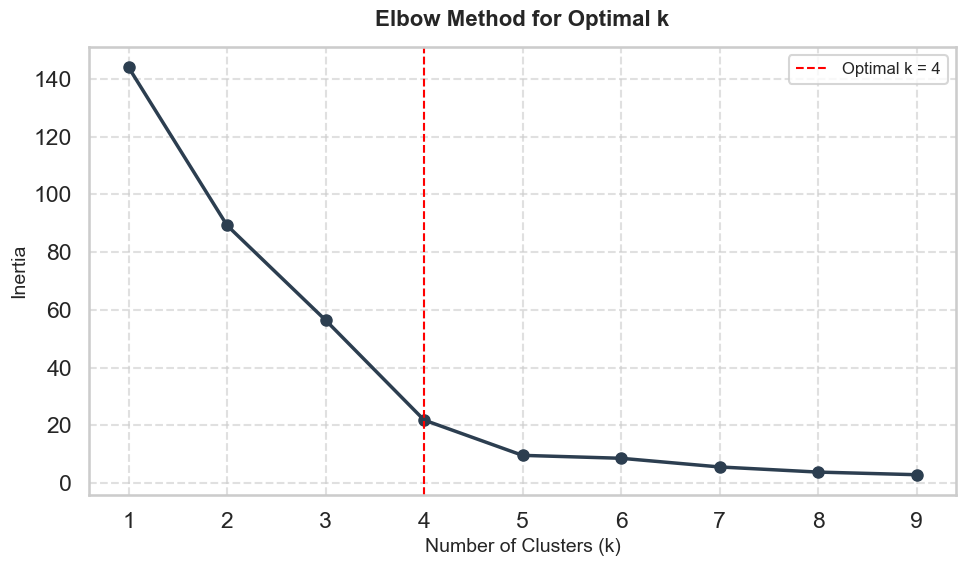

In [239]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Set up your scaled feature matrix
# X_scaled = your standardized data (e.g., from StandardScaler)

# Step 2: Compute inertia for each K
k_range = range(1, 10)
inertia = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Step 3: Plot with clean style
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid', context='talk')

plt.plot(k_range, inertia, marker='o', markersize=8, linewidth=2.5, color="#2C3E50")
plt.xticks(k_range)
plt.xlabel("Number of Clusters (k)", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.title("Elbow Method for Optimal k", fontsize=16, weight='bold', pad=15)

# Optional highlight
best_k = 4  # or the number you choose visually
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f"Optimal k = {best_k}")
plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




In [233]:
from sklearn.cluster import KMeans

# Run KMeans with optimal k = 4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = clusters


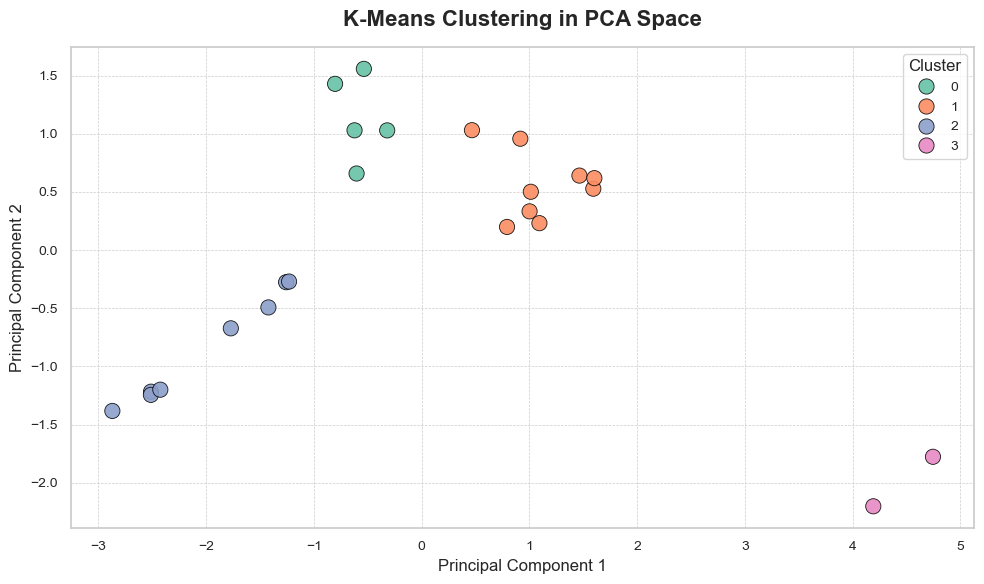

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid', context='notebook')

palette = sns.color_palette("Set2", df_clustered['Cluster'].nunique())

sns.scatterplot(
    data=df_clustered, 
    x='PC1', y='PC2', 
    hue='Cluster', 
    palette=palette, 
    s=120, edgecolor='black', linewidth=0.6, alpha=0.9
)

plt.title("K-Means Clustering in PCA Space", fontsize=16, weight='bold', pad=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Cluster', title_fontsize=12, fontsize=10, loc='best')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [240]:
# Assuming `df_pca` has the PCA-transformed data
# And `df` is your original dataframe with 'Year'

df['Cluster'] = kmeans.labels_  # Add cluster labels back to the original data


In [242]:
print(df.columns)


Index(['Years', 'ID', 'Country', 'Trade', 'Agriculture', 'Industry', 'Service',
       'GDPcap', 'Electricity', 'Mobile', 'Import', 'Export', 'Population',
       'Governance', 'Cluster'],
      dtype='object')


C:\Users\dirir\AppData\Local\Temp\ipykernel_28052\863975408.py:52: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dirir\Downloads\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


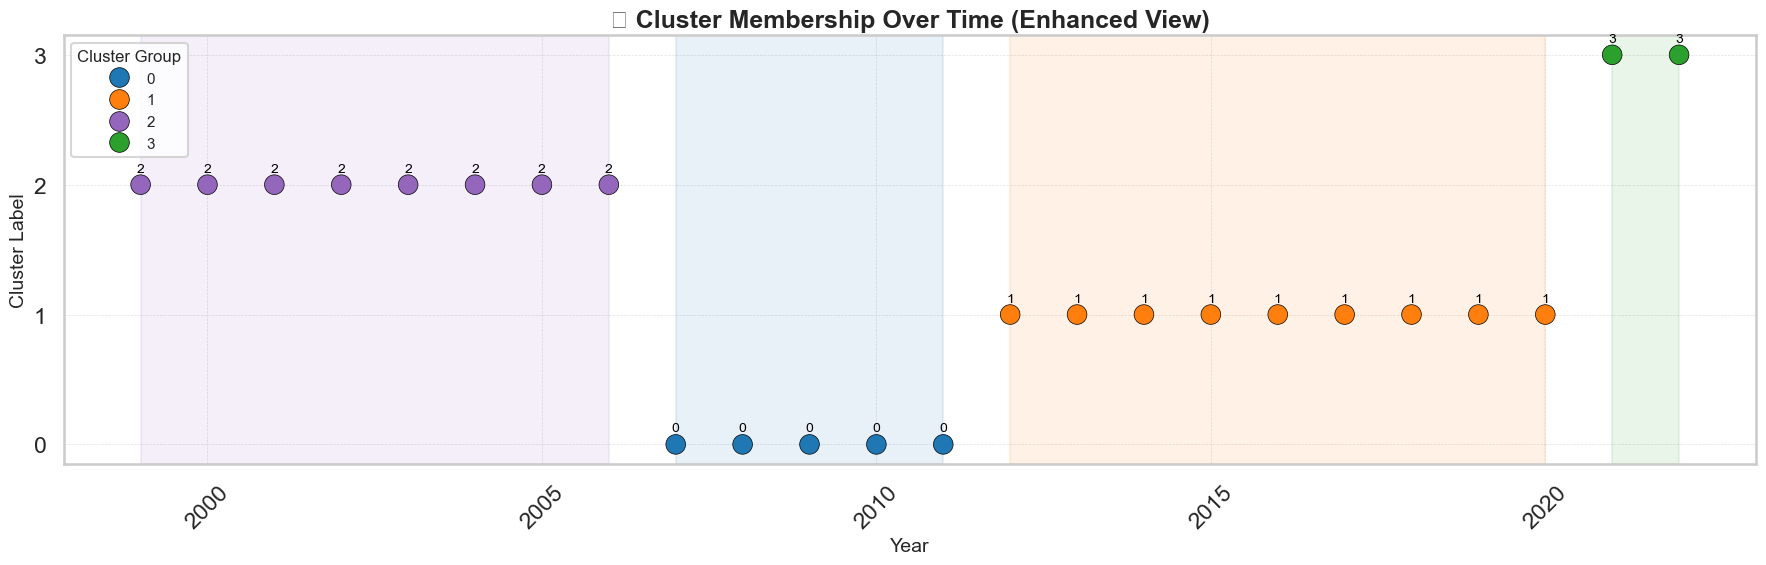

In [245]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(18, 6))

# Define custom palette
palette = {
    0: "#1f77b4",  # blue
    1: "#ff7f0e",  # orange
    2: "#9467bd",  # purple
    3: "#2ca02c",  # green
}

# Sort by year just in case
df_sorted = df.sort_values(by='Years')

# Draw shaded regions for each cluster group
for cluster_label in df_sorted['Cluster'].unique():
    cluster_years = df_sorted[df_sorted['Cluster'] == cluster_label]['Years']
    plt.axvspan(cluster_years.min(), cluster_years.max(), alpha=0.1, color=palette[cluster_label])

# Plot cluster membership
sns.scatterplot(
    data=df_sorted,
    x='Years',
    y='Cluster',
    hue='Cluster',
    palette=palette,
    s=200,
    edgecolor='black',
    linewidth=0.5,
    legend='full'
)

# Annotations on top of scatter
for i, row in df_sorted.iterrows():
    plt.text(row['Years'], row['Cluster'] + 0.1, str(int(row['Cluster'])), 
             horizontalalignment='center', fontsize=10, color='black')

# Formatting
plt.title("📌 Cluster Membership Over Time (Enhanced View)", fontsize=18, weight='bold')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Cluster Label", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(sorted(df_sorted['Cluster'].unique()))
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Legend tweaks
plt.legend(title='Cluster Group', title_fontsize=12, fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()


In [250]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is called df and has columns: 'Cluster', 'Industry', 'Service'

# Group by cluster and compute mean shares
cluster_profile = df.groupby('Cluster')[['Industry', 'Service']].mean().reset_index()

print(cluster_profile)


   Cluster   Industry    Service
0        0  18.958957  77.297921
1        1  21.581915  75.021349
2        2  15.882777  80.812454
3        3  15.810299  76.115858



--- ENHANCED GROUPED DOT PLOT with CONNECTED PROFILES (Nature Aesthetic) ---


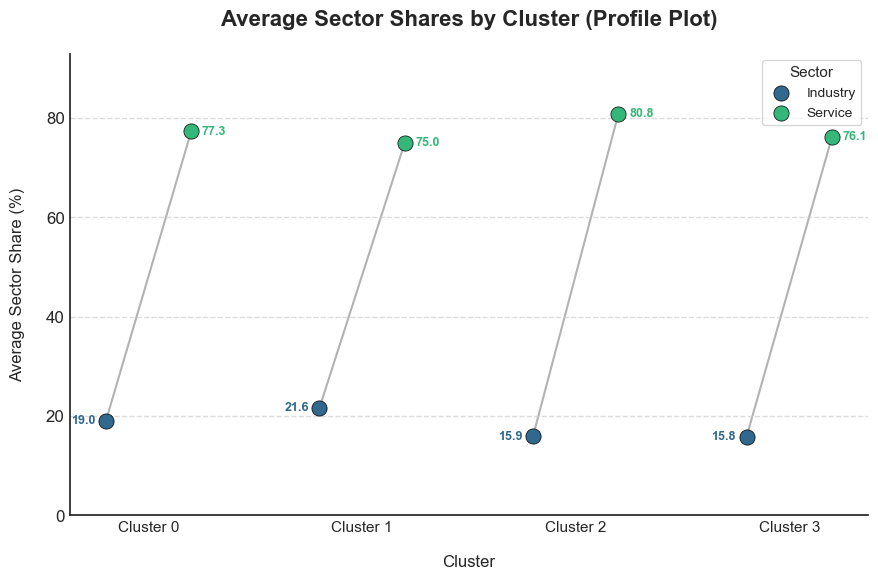


Generated an Enhanced Grouped Dot Plot with Connected Profiles.


In [260]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# --- YOUR ACTUAL 'cluster_profile' DataFrame ---
cluster_profile = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Industry': [18.958957, 21.581915, 15.882777, 15.810299],
    'Service': [77.297921, 75.021349, 80.812454, 76.115858]
})

print("\n--- ENHANCED GROUPED DOT PLOT with CONNECTED PROFILES (Nature Aesthetic) ---")

# Melt the data for seaborn-friendly format
cluster_melted = cluster_profile.melt(id_vars='Cluster', value_vars=['Industry', 'Service'],
                                      var_name='Sector', value_name='Average Share')

plt.figure(figsize=(9, 6)) # Adjusted for a clean look
sns.set_theme(style="white", palette="Set1", font_scale=1.1) # 'white' for clean background, 'Set1' for distinct colors

ax = plt.subplot(111)

# Sort clusters for consistent plotting order
df_plot = cluster_melted.sort_values(by=['Cluster', 'Sector'])

# Create custom x-positions for each cluster group
# This ensures dots for Industry and Service are horizontally offset for clarity
num_clusters = len(cluster_profile['Cluster'].unique())
x_base = np.arange(num_clusters) # 0, 1, 2, 3 for clusters
offset = 0.2 # Offset for Industry/Service dots

# Get distinct colors for Industry and Service
sector_colors = sns.color_palette("viridis", n_colors=2) # Using viridis colors
industry_color = sector_colors[0]
service_color = sector_colors[1]

# Plot lines connecting Industry and Service for each cluster
for i, cluster in enumerate(cluster_profile['Cluster']):
    industry_share = cluster_profile[cluster_profile['Cluster'] == cluster]['Industry'].values[0]
    service_share = cluster_profile[cluster_profile['Cluster'] == cluster]['Service'].values[0]
    
    # Plot the connecting line
    ax.plot([x_base[i] - offset, x_base[i] + offset], [industry_share, service_share],
            color='gray', linestyle='-', linewidth=1.5, alpha=0.6, zorder=0)

# Plot dots for Industry
ax.scatter(x=[x - offset for x in x_base], y=cluster_profile['Industry'],
           s=120, color=industry_color, label='Industry', edgecolors='black', linewidth=0.5, zorder=1)

# Plot dots for Service
ax.scatter(x=[x + offset for x in x_base], y=cluster_profile['Service'],
           s=120, color=service_color, label='Service', edgecolors='black', linewidth=0.5, zorder=1)

# Add value labels next to the dots
for i, row in cluster_profile.iterrows():
    # Industry label
    ax.text(x_base[i] - offset - 0.05, row['Industry'], f'{row["Industry"]:.1f}',
            ha='right', va='center', fontsize=9, color=industry_color, fontweight='bold')
    # Service label
    ax.text(x_base[i] + offset + 0.05, row['Service'], f'{row["Service"]:.1f}',
            ha='left', va='center', fontsize=9, color=service_color, fontweight='bold')


# Set x-axis labels to be the cluster names
ax.set_xticks(x_base)
ax.set_xticklabels([f'Cluster {int(c)}' for c in cluster_profile['Cluster']], fontsize=11)

plt.title("Average Sector Shares by Cluster (Profile Plot)",
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Average Sector Share (%)", fontsize=12, labelpad=15)
plt.xlabel("Cluster", fontsize=12, labelpad=15)
plt.ylim(bottom=0, top=cluster_melted['Average Share'].max() * 1.15) # Buffer for labels

# Improve legend appearance and placement
plt.legend(title='Sector', loc='upper right', frameon=True, fancybox=True, shadow=False, fontsize=10, title_fontsize=11)

# Clean up grid and spines for a 'Nature' look
sns.despine(left=False, bottom=False) # Keep bottom/left
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0) # Only subtle horizontal grid
ax.tick_params(axis='x', length=0) # Remove x-axis ticks
ax.tick_params(axis='y', length=0) # Remove y-axis ticks
ax.set_axisbelow(True) # Ensure grid is behind the points and lines

plt.tight_layout()
plt.show()

print("\nGenerated an Enhanced Grouped Dot Plot with Connected Profiles.")

In [266]:
pip install geopandas matplotlib contextily


   ---------------------------------------- 0/2 [mercantile]
   -------------------- ------------------- 1/2 [contextily]
   ---------------------------------------- 2/2 [contextily]

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [5]:
from IPython.display import IFrame
import os

# Define the exact path to YOUR HTML map file
map_file_path = r"C:\Users\dirir\Downloads\IGAD countries\heatmap_clusters.html"

# Check if the file exists
if os.path.exists(map_file_path):
    # Get the file size (optional, but good for large files)
    file_size = os.path.getsize(map_file_path)

    # Use IPython.display.IFrame to embed the HTML file
    # The width and height parameters control the size of the embedded frame in Jupyter
    # You might need to adjust width='100%' and height=600 based on your preference
    display(IFrame(src=map_file_path, width='100%', height=600))

    print(f"Map '{map_file_path}' embedded successfully within Jupyter output.")
else:
    print(f"ERROR: The map file was not found at '{map_file_path}'.")
    print("Please double-check the path and ensure the file exists there.")

Map 'C:\Users\dirir\Downloads\IGAD countries\heatmap_clusters.html' embedded successfully within Jupyter output.


World GeoJSON data loaded successfully from URL.

Found Djibouti for base outline.
ERROR: Could not load Admin 1 shapefile from 'C:\Users\dirir\Downloads\IGAD countries\ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp'. Error: C:\Users\dirir\Downloads\IGAD countries\ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp: No such file or directory
Skipping Admin 1 layer.
ERROR: Could not load Populated Places shapefile from 'C:\Users\dirir\Downloads\IGAD countries\ne_10m_populated_places\ne_10m_populated_places.shp'. Error: C:\Users\dirir\Downloads\IGAD countries\ne_10m_populated_places\ne_10m_populated_places.shp: No such file or directory
Skipping Populated Places layer.


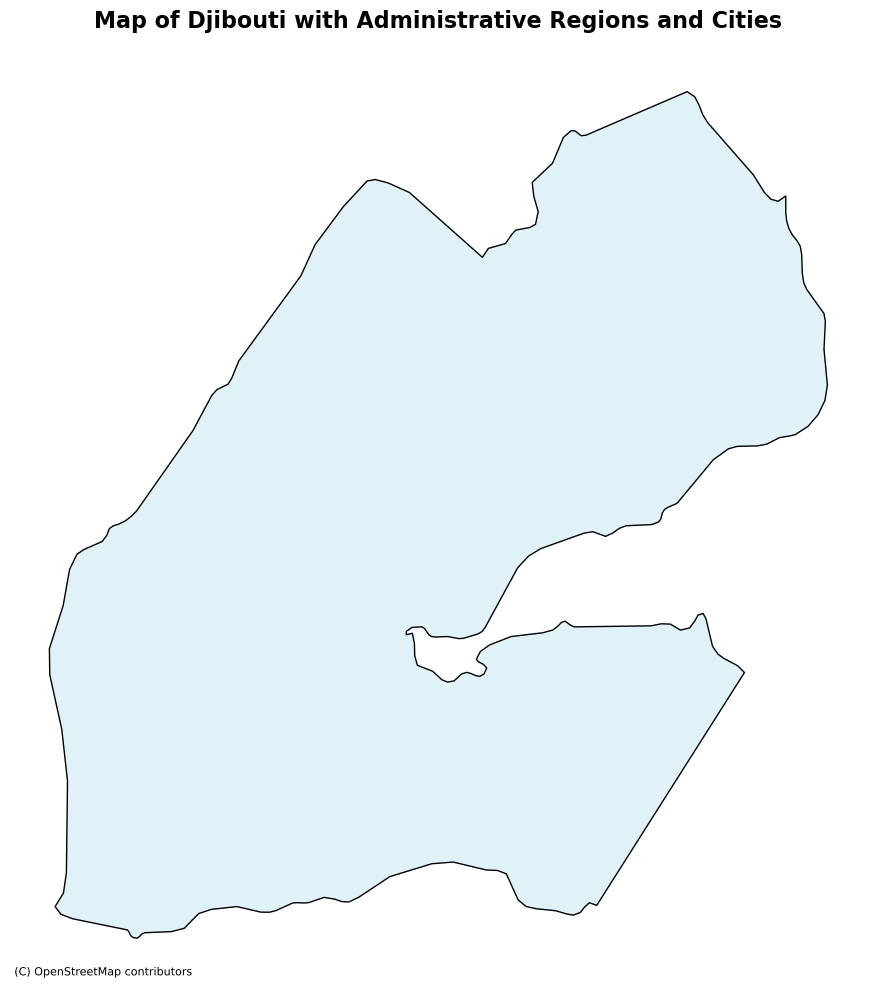


Map with details saved successfully to: C:\Users\dirir\Downloads\IGAD countries\Map_of_Djibouti_Details.png

Detailed map generation complete.


In [6]:
import geopandas
import matplotlib.pyplot as plt
import contextily as cx

# --- Configuration ---
# 1. Base Country Data (from URL - confirmed working)
geojson_url = "https://raw.githubusercontent.com/datasets/geo-countries/main/data/countries.geojson"
country_to_map = 'Djibouti'

# 2. Paths to NEWLY DOWNLOADED SHAPEFILES (YOU MUST UNZIP AND UPDATE THESE PATHS)
#    - Downloaded from Natural Earth 10m Cultural Vectors
admin1_shapefile_path = r"C:\Users\dirir\Downloads\IGAD countries\ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp"
places_shapefile_path = r"C:\Users\dirir\Downloads\IGAD countries\ne_10m_populated_places\ne_10m_populated_places.shp"

# --- Step 1: Load Base Country GeoJSON from URL ---
try:
    world = geopandas.read_file(geojson_url)
    print("World GeoJSON data loaded successfully from URL.")
except Exception as e:
    print(f"CRITICAL ERROR: Could not load GeoJSON data from URL. Error: {e}")
    exit()

# --- Step 2: Filter for Djibouti (Base Country Outline) ---
djibouti_country_outline = world[world['name'] == country_to_map].copy()
if djibouti_country_outline.empty:
    print(f"ERROR: Could not find '{country_to_map}' in the dataset.")
    exit()
print(f"\nFound {country_to_map} for base outline.")

# --- Step 3: Load Additional Shapefiles (Admin 1 and Populated Places) ---
try:
    admin1_data = geopandas.read_file(admin1_shapefile_path)
    print("Admin 1 data loaded successfully.")
    # For Admin 1, the country name is usually in 'adm0_a3' (ISO 3-letter code)
    # Djibouti's ISO 3-letter code is 'DJI'
    djibouti_admin1 = admin1_data[admin1_data['adm0_a3'] == 'DJI'].copy()
    if djibouti_admin1.empty:
        print(f"Warning: No Admin 1 (regions) found for {country_to_map} (DJI). Check 'adm0_a3' column.")
    else:
        print(f"Found {len(djibouti_admin1)} administrative regions for {country_to_map}.")
        # Ensure projection consistency with base country outline if plotting on the same axis later
        if djibouti_country_outline.crs and djibouti_admin1.crs != djibouti_country_outline.crs:
             djibouti_admin1 = djibouti_admin1.to_crs(djibouti_country_outline.crs)

except Exception as e:
    print(f"ERROR: Could not load Admin 1 shapefile from '{admin1_shapefile_path}'. Error: {e}")
    print("Skipping Admin 1 layer.")
    djibouti_admin1 = geopandas.GeoDataFrame() # Create empty GeoDataFrame to prevent errors


try:
    places_data = geopandas.read_file(places_shapefile_path)
    print("Populated Places data loaded successfully.")
    # Filter places within Djibouti's bounding box for efficiency, then spatially
    # For populated places, the country code is often in 'ADM0_A3' (for 10m) or 'iso_a3'
    if 'ADM0_A3' in places_data.columns:
        djibouti_places = places_data[places_data['ADM0_A3'] == 'DJI'].copy()
    elif 'iso_a3' in places_data.columns: # Sometimes 'iso_a3' in other versions
        djibouti_places = places_data[places_data['iso_a3'] == 'DJI'].copy()
    else:
        print("Warning: Neither 'ADM0_A3' nor 'iso_a3' found for country code in populated places.")
        djibouti_places = geopandas.GeoDataFrame() # Empty if cannot filter

    if djibouti_places.empty and ('ADM0_A3' in places_data.columns or 'iso_a3' in places_data.columns):
        print(f"Warning: No populated places found for {country_to_map} (DJI). Check 'ADM0_A3'/'iso_a3' column.")
        print(f"Sample country codes in places data: {places_data['ADM0_A3'].unique()[:5].tolist() if 'ADM0_A3' in places_data.columns else 'N/A'}")
    elif not djibouti_places.empty:
        print(f"Found {len(djibouti_places)} populated places for {country_to_map}.")
        # Ensure projection consistency
        if djibouti_country_outline.crs and djibouti_places.crs != djibouti_country_outline.crs:
             djibouti_places = djibouti_places.to_crs(djibouti_country_outline.crs)

except Exception as e:
    print(f"ERROR: Could not load Populated Places shapefile from '{places_shapefile_path}'. Error: {e}")
    print("Skipping Populated Places layer.")
    djibouti_places = geopandas.GeoDataFrame() # Create empty GeoDataFrame


# --- Step 4: Create the Map and Overlay Layers ---
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 4.1 Plot Base Country Outline (The "Country border" you already had)
djibouti_country_outline.plot(ax=ax, color='#e0f2f7', edgecolor='black', linewidth=1)

# 4.2 Plot Administrative Regions (if loaded successfully)
if not djibouti_admin1.empty:
    djibouti_admin1.plot(ax=ax, edgecolor='darkblue', linewidth=0.7, facecolor='none', alpha=0.7) # Plot just borders
    print("Admin 1 (regions) added to map.")

# 4.3 Plot Populated Places (if loaded successfully)
if not djibouti_places.empty:
    # Use 'name' column for city labels (often exists in Populated Places)
    # Filter for major cities (e.g., 'SCALERANK' from Natural Earth for size)
    # Check if 'SCALERANK' exists before using it
    if 'SCALERANK' in djibouti_places.columns:
        major_cities = djibouti_places[djibouti_places['SCALERANK'] <= 5] # Example: show larger cities
    else:
        major_cities = djibouti_places # If no scalerank, plot all

    major_cities.plot(ax=ax, marker='o', color='red', markersize=30, edgecolor='white', alpha=0.8, zorder=5)
    # Add city names
    for x, y, label in zip(major_cities.geometry.x, major_cities.geometry.y, major_cities['name']):
        ax.text(x, y, label, fontsize=8, ha='center', va='bottom', color='black', weight='bold', zorder=6)
    print("Populated Places (cities) added to map.")


# Customize plot aesthetics
ax.set_title(f'Map of {country_to_map} with Administrative Regions and Cities', fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off() # Remove axes ticks and labels for a cleaner map

# --- Step 5: Add a Basemap for Context ---
# Reproject to Web Mercator for contextily if not already (using the base country outline)
if djibouti_country_outline.crs is None or djibouti_country_outline.crs.to_string() != 'EPSG:3857':
    try:
        djibouti_proj_base = djibouti_country_outline.to_crs(epsg=3857)
    except Exception as e:
        print(f"Warning: Could not reproject base country outline to EPSG:3857. Basemap might not align. Error: {e}")
        djibouti_proj_base = djibouti_country_outline
else:
    djibouti_proj_base = djibouti_country_outline

manual_zoom_level = 10 # Adjust zoom level (e.g., 8, 10, 12)
try:
    cx.add_basemap(ax, crs=djibouti_proj_base.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik, zoom=manual_zoom_level)
except Exception as e:
    print(f"Warning: Could not add basemap. Error: {e}")


plt.tight_layout()
plt.show()

# --- Step 6: Save the map ---
save_directory = r"C:\Users\dirir\Downloads\IGAD countries"
file_name = f"Map_of_{country_to_map}_Details.png"
full_save_path = f"{save_directory}\\{file_name}"

try:
    fig.savefig(full_save_path, dpi=300, bbox_inches='tight', transparent=False)
    print(f"\nMap with details saved successfully to: {full_save_path}")
except Exception as e:
    print(f"\nError saving map with details: {e}")

print("\nDetailed map generation complete.")